# Iris Flower Classification using Decision Tree

**Repositori**: Machine Learning  
**Topik**: Klasifikasi Spesies Bunga Iris dengan Decision Tree  
**Dataset**: Iris Dataset (Scikit-Learn built-in)  

---

## Pendahuluan
Decision Tree adalah algoritma supervised learning yang membagi data berdasarkan nilai fitur paling signifikan, membentuk struktur seperti pohon. Proyek ini mengklasifikasikan 3 spesies Iris (*Setosa, Versicolor, Virginica*) berdasarkan 4 fitur morfologis.

### Pipeline:
1. **Data Acquisition** — Muat dataset Iris dari Scikit-Learn
2. **EDA** — Analisis distribusi fitur dan target
3. **Data Preparation** — Split train/test
4. **Modeling** — Decision Tree
5. **Evaluation** — Confusion Matrix + Classification Report
6. **Visualization** — Plot struktur Decision Tree

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Data Acquisition
Memuat dataset Iris dari Scikit-Learn.

In [2]:
iris = load_iris()
X = iris['data']
y = iris['target']
feature_names = iris['feature_names']
target_names = iris['target_names']

df = pd.DataFrame(X, columns=feature_names)
df['Species'] = y
df['Species'] = df['Species'].map(dict(enumerate(target_names)))

print(f"Shape: {X.shape}")
df.head()

Shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. Exploratory Data Analysis

In [3]:
print("Statistik Deskriptif:")
print(df.describe())

print("\nDistribusi Target:")
print(df['Species'].value_counts())

Statistik Deskriptif:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  

Distribusi Target:
Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


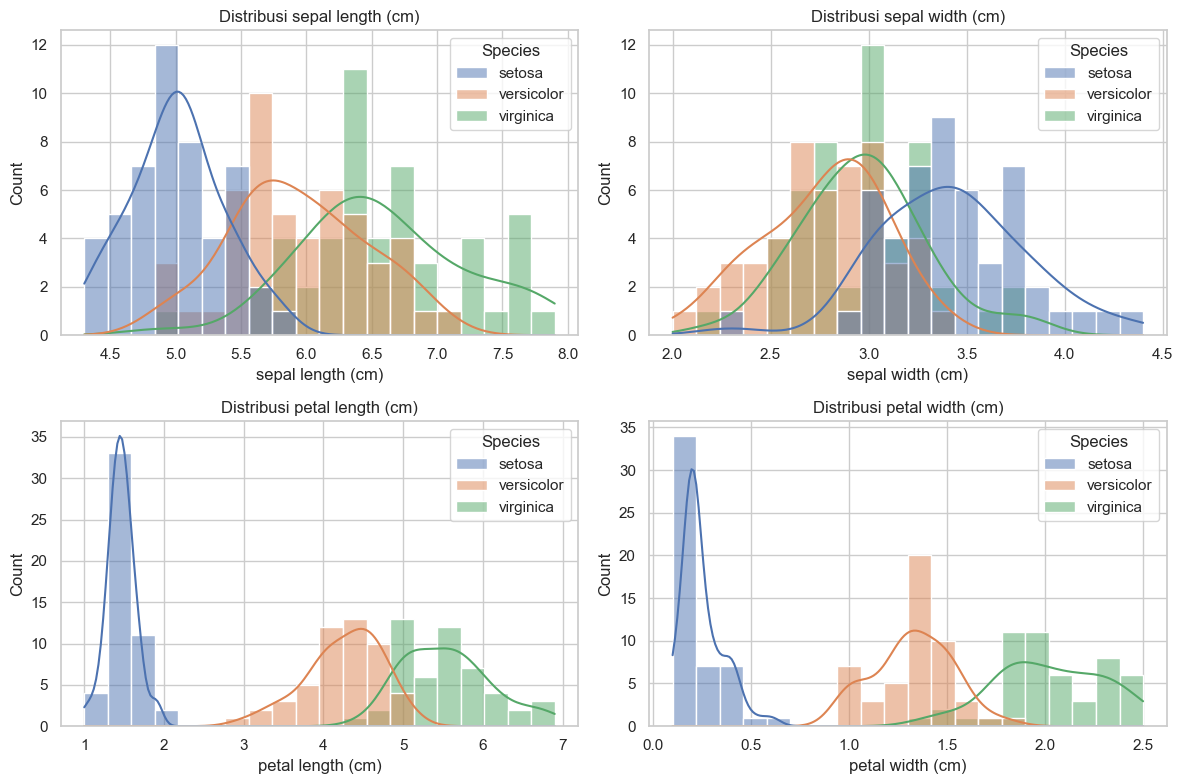

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(feature_names):
    sns.histplot(data=df, x=col, hue='Species', bins=20, kde=True, ax=axes[i // 2, i % 2])
    axes[i // 2, i % 2].set_title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

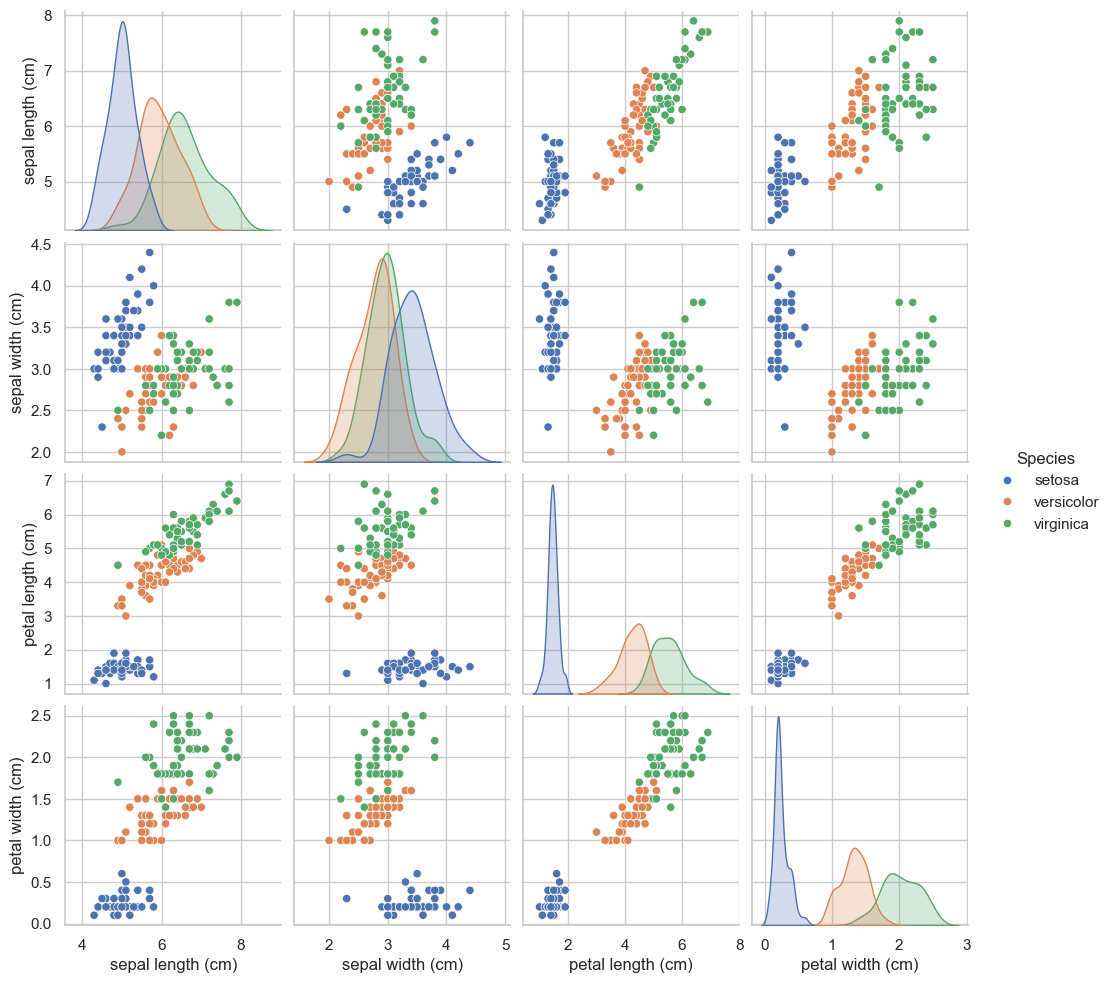

In [5]:
sns.pairplot(df, hue='Species', diag_kind='kde')
plt.show()

## 3. Data Preparation
Split data menjadi Training dan Test set (80/20).

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

print(f"Train size: {X_train.shape[0]} samples")
print(f"Test size:  {X_test.shape[0]} samples")

Train size: 120 samples
Test size:  30 samples


## 4. Model Training
Membangun Decision Tree Classifier.

In [7]:
model = DecisionTreeClassifier(random_state=0)
model.fit(X_train, y_train)
print("Model trained:", model)

Model trained: DecisionTreeClassifier(random_state=0)


## 5. Prediction & Evaluation

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]


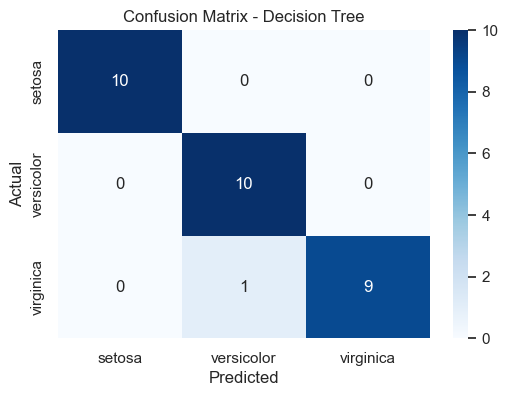


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [8]:
y_pred = model.predict(X_test)

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

## 6. Prediksi Sampel Baru
Menguji model dengan satu sampel observasi.

In [9]:
observation = np.array([[5.1, 3.5, 1.4, 0.2]])  # Setosa
prediction = model.predict(observation)
proba = model.predict_proba(observation)

print(f"Predicted class: {target_names[prediction][0]}")
print(f"Probabilities: {dict(zip(target_names, proba[0]))}")

Predicted class: setosa
Probabilities: {np.str_('setosa'): np.float64(1.0), np.str_('versicolor'): np.float64(0.0), np.str_('virginica'): np.float64(0.0)}


## 7. Visualisasi Decision Tree

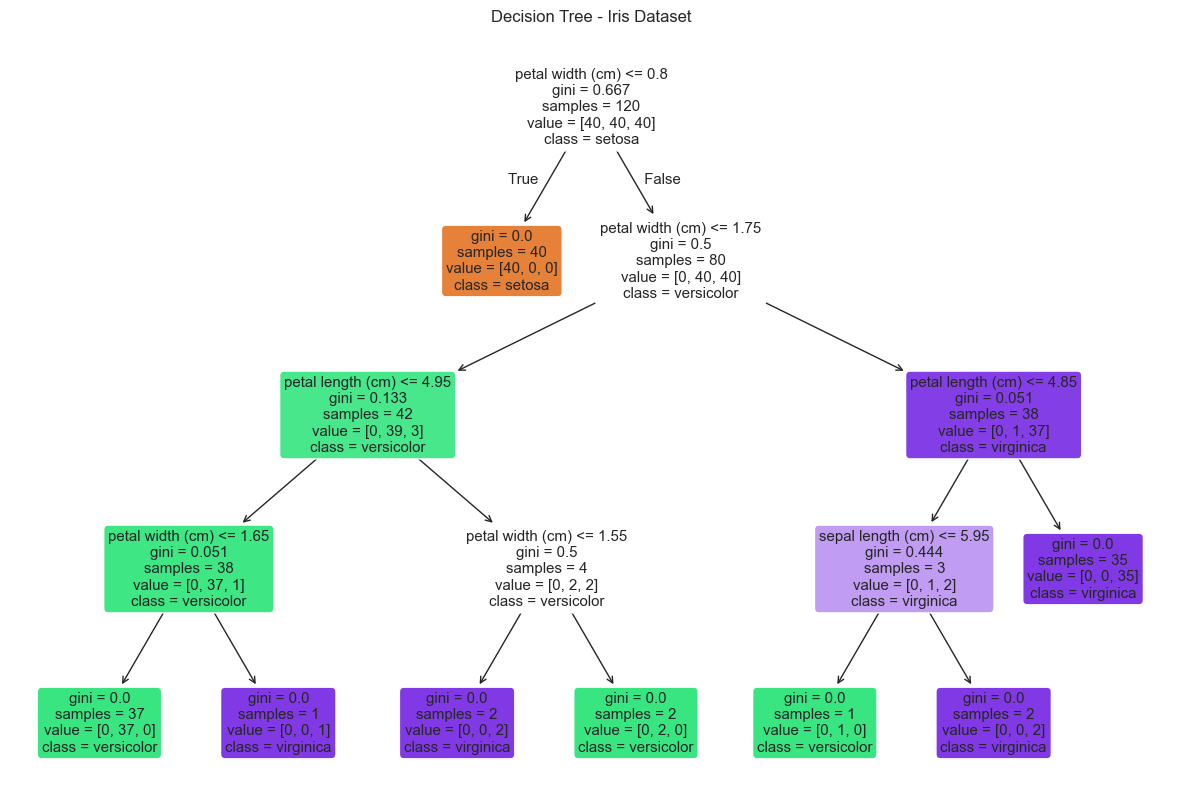

In [10]:
plt.figure(figsize=(15, 10))
plot_tree(model, feature_names=feature_names, class_names=target_names,
          filled=True, rounded=True)
plt.title('Decision Tree - Iris Dataset')
plt.savefig('iris.png')
plt.show()

## Kesimpulan
Decision Tree mampu mengklasifikasikan 3 spesies Iris dengan akurasi tinggi pada test set. Fitur *petal length* dan *petal width* menjadi pemisah paling dominan. Visualisasi pohon menunjukkan aturan keputusan yang mudah diinterpretasikan.